In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
from collections import OrderedDict
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.stats import pearsonr, spearmanr
from itertools import combinations
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
import joblib
import shap

In [23]:
FINAL_CLASSES = ["AF", "IAVB", "LAD", "LBBB", "NSIVCB", "NSR", "PAC", "QAb", "RBBB", "SB", "STach", "TAb"]
PROCESSED_DIR = r"C:\ECG_Project\training\processed_signals"
SPLIT_CSV_PATH = r"C:\ECG_Project\training\ecg_metadata_train_test_split.csv"
FEDERATED_CLIENTS = ["chapman_shaoxing", "cpsc_2018", "georgia", "ningbo", "ptb-xl"]
FIGDIR = r"C:\ECG_Project\training\figures"

In [13]:
class ResidualBlock1D(nn.Module):
    """
    One residual block: two conv layers + a skip connection.
    If input/output channels differ, or stride > 1, the skip connection
    uses a 1x1 conv to match dimensions.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = F.relu(out)
        return out


class ResNet1D34(nn.Module):
    """
    1D ResNet-34, adapted for 12-lead ECG classification.
    stem -> 4 stages of residual blocks -> global pool -> classifier head
    """
    def __init__(self, in_channels=12, num_classes=12):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # ResNet-34 recipe: [3, 4, 6, 3] blocks per stage
        self.layer1 = self._make_layer(64, 64, num_blocks=3, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=4, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=6, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=3, stride=2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [ResidualBlock1D(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x


if __name__ == "__main__":
    # Sanity check with dummy data — run this file directly to verify the architecture
    model = ResNet1D34(in_channels=12, num_classes=12)

    dummy_input = torch.randn(4, 12, 5000)
    output = model(dummy_input)

    total_params = sum(p.numel() for p in model.parameters())

In [15]:
class ResNet1D34_MCDropout(ResNet1D34):
    """
    Same architecture as ResNet1D34, with one added Dropout layer before the
    final FC layer. Dropout has ZERO learnable parameters, so existing
    FedAvg/FedProx/Central checkpoints (trained WITHOUT this layer) load in
    directly via load_state_dict() -- no retraining needed.
    """
    def __init__(self, in_channels=12, num_classes=12, dropout_p=0.3):
        super().__init__(in_channels=in_channels, num_classes=num_classes)
        self.mc_dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.mc_dropout(x)     # ONLY new line vs. the original forward()
        x = self.fc(x)
        return x


def enable_mc_dropout(model):
    """
    Puts the WHOLE model in eval mode (so BatchNorm uses running stats, not
    batch stats -- critical, since batch stats would themselves add noise we
    don't want) EXCEPT the dropout layer, which stays in train mode so it
    keeps randomly zeroing activations across repeated forward passes.
    """
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

In [5]:
class ECGDataset(Dataset):
    """
    Loads preprocessed (12, 5000) .npy signals + multi-label targets
    for one specific hospital client and split (train/test).

    Defensive by design: filters out any record whose .npy file doesn't
    actually exist on disk, at __init__ time — not mid-training. This is
    the fix for the FileNotFoundError bug from Stage 4; baking it in here
    means it can never resurface, even if a metadata CSV gets stale again.
    """
    def __init__(self, metadata_df: pd.DataFrame, processed_dir: str,
                 source_hospital: str, split: str):
        candidate_df = metadata_df[
            (metadata_df["source_hospital"] == source_hospital) &
            (metadata_df["split"] == split)
        ].reset_index(drop=True)

        exists_mask = candidate_df["record_id"].apply(
            lambda rid: Path(f"{processed_dir}/{rid}.npy").exists()
        )
        dropped = (~exists_mask).sum()
        if dropped > 0:
            print(f"  [{source_hospital}/{split}] Skipping {dropped} records with missing .npy files")

        self.df = candidate_df[exists_mask].reset_index(drop=True)
        self.processed_dir = processed_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        record_id = row["record_id"]

        signal = np.load(f"{self.processed_dir}/{record_id}.npy")
        label = row[FINAL_CLASSES].values.astype(np.float32)

        return torch.tensor(signal, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

def build_client_loaders(metadata_df: pd.DataFrame, federated_clients: list,
                          processed_dir: str = PROCESSED_DIR, batch_size: int = 16):
    """
    Builds one train + test DataLoader pair per hospital client.
    Returns a dict: { hospital_name: {"train": loader, "test": loader, "train_size": int} }
    """
    client_loaders = {}
    for hospital in federated_clients:
        train_ds = ECGDataset(metadata_df, processed_dir, hospital, "train")
        test_ds = ECGDataset(metadata_df, processed_dir, hospital, "test")

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

        client_loaders[hospital] = {
            "train": train_loader,
            "test": test_loader,
            "train_size": len(train_ds),
        }
        print(f"{hospital}: {len(train_ds)} train / {len(test_ds)} test")

    return client_loaders


if __name__ == "__main__":

    FEDERATED_CLIENTS = ["chapman_shaoxing", "cpsc_2018", "georgia", "ningbo", "ptb-xl"]

    metadata_df = pd.read_csv(SPLIT_CSV_PATH)
    client_loaders = build_client_loaders(metadata_df, FEDERATED_CLIENTS)

    # End-to-end sanity check: pull one real batch through the model
    model = ResNet1D34(in_channels=12, num_classes=12)

    test_hospital = "georgia"
    batch_signals, batch_labels = next(iter(client_loaders[test_hospital]["train"]))
    print(f"\nBatch signals shape: {batch_signals.shape}")   # expect (16, 12, 5000)
    print(f"Batch labels shape: {batch_labels.shape}")       # expect (16, 12)

    test_output = model(batch_signals)
    print(f"Model output shape on real batch: {test_output.shape}")   # expect (16, 12)

chapman_shaoxing: 7522 train / 1885 test
cpsc_2018: 4794 train / 1200 test
georgia: 6520 train / 1641 test
ningbo: 22246 train / 5594 test
ptb-xl: 16829 train / 4203 test

Batch signals shape: torch.Size([16, 12, 5000])
Batch labels shape: torch.Size([16, 12])
Model output shape on real batch: torch.Size([16, 12])


In [7]:
def get_model_parameters(model):
    """Extract model weights as a plain state_dict (for aggregation)."""
    return model.state_dict()


def set_model_parameters(model, state_dict):
    """Load a state_dict back into the model."""
    model.load_state_dict(state_dict, strict=True)


def train_one_client(model, train_loader, device, epochs=1, lr=1e-3):
    model.to(device)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        total_loss = 0.0
        n_batches = 0
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(signals)
            loss = criterion(outputs, labels)

            if not torch.isfinite(loss):
                print("  Skipping a batch with non-finite loss")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
    return avg_loss


def evaluate_one_client(model, test_loader, device):
    model.to(device)
    model.eval()
    criterion = nn.BCEWithLogitsLoss()

    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for signals, labels in test_loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / len(test_loader)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    micro_precision = precision_score(all_labels, all_preds, average="micro", zero_division=0)
    micro_recall = recall_score(all_labels, all_preds, average="micro", zero_division=0)

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)      # NEW
    macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)  # NEW
    macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)        # NEW

    return avg_loss, micro_f1, micro_precision, micro_recall, macro_f1, macro_precision, macro_recall

In [11]:
MODEL_CHECKPOINTS = {
    "fedavg":  r"C:\ECG_Project\training\fedavg\global_model_round30.pt",
    "fedprox": r"C:\ECG_Project\training\fedprox_mu0.001\fedprox_global_model_round30.pt",
    "fedopt":  r"C:\ECG_Project\training\fedopt\fedopt_global_model_round30.pt",
}

N_MC_PASSES = 30          # standard MC Dropout sample count
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_PATH = r"C:\ECG_Project\training\mc_dropout_uncertainty.csv"


def compute_mc_dropout_uncertainty(model, test_loader, device, n_passes=N_MC_PASSES):
    """
    For every record, runs n_passes stochastic forward passes (dropout active),
    and returns per-record: mean prediction (sigmoid probs) and uncertainty
    (std across passes) for each of the 12 classes.
    """
    enable_mc_dropout(model)

    all_record_ids = []
    all_means = []
    all_stds = []

    record_idx = 0
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            batch_size = signals.shape[0]

            pass_outputs = []
            for _ in range(n_passes):
                outputs = torch.sigmoid(model(signals))     # (batch, 12)
                pass_outputs.append(outputs.cpu().numpy())

            pass_outputs = np.stack(pass_outputs, axis=0)    # (n_passes, batch, 12)
            mean_pred = pass_outputs.mean(axis=0)             # (batch, 12)
            std_pred = pass_outputs.std(axis=0)                # (batch, 12) -- the uncertainty

            all_means.append(mean_pred)
            all_stds.append(std_pred)
            record_idx += batch_size

    all_means = np.concatenate(all_means, axis=0)
    all_stds = np.concatenate(all_stds, axis=0)
    return all_means, all_stds


def run_uncertainty_for_all(metadata_df):
    results = []

    for model_name, ckpt_path in MODEL_CHECKPOINTS.items():
        print(f"\n=== MC Dropout: {model_name} ===")
        model = ResNet1D34_MCDropout(in_channels=12, num_classes=12).to(device=DEVICE)
        state_dict = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(state_dict, strict=False)   # strict=False: mc_dropout has no saved weights, that's expected
        model.to(DEVICE)

        for hospital in FEDERATED_CLIENTS:
            test_ds = ECGDataset(metadata_df, PROCESSED_DIR, hospital, "test")
            test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

            record_ids = test_ds.df["record_id"].tolist()
            means, stds = compute_mc_dropout_uncertainty(model, test_loader, DEVICE)

            print(f"  [{hospital}] n={len(record_ids)}  mean uncertainty (avg across classes)={stds.mean():.4f}")

            for i, rid in enumerate(record_ids):
                row = {"model": model_name, "hospital": hospital, "record_id": rid}
                for c_idx, cls in enumerate(FINAL_CLASSES):
                    row[f"{cls}_mean_pred"] = means[i, c_idx]
                    row[f"{cls}_uncertainty"] = stds[i, c_idx]
                results.append(row)

    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_PATH, index=False)
    print(f"\nSaved: {OUTPUT_PATH}, shape={results_df.shape}")
    return results_df


metadata_df = pd.read_csv(SPLIT_CSV_PATH)
uncertainty_df = run_uncertainty_for_all(metadata_df)


=== MC Dropout: fedavg ===
  [chapman_shaoxing] n=1885  mean uncertainty (avg across classes)=0.0148
  [cpsc_2018] n=1200  mean uncertainty (avg across classes)=0.0165
  [georgia] n=1641  mean uncertainty (avg across classes)=0.0157
  [ningbo] n=5594  mean uncertainty (avg across classes)=0.0148
  [ptb-xl] n=4203  mean uncertainty (avg across classes)=0.0127

=== MC Dropout: fedprox ===
  [chapman_shaoxing] n=1885  mean uncertainty (avg across classes)=0.0238
  [cpsc_2018] n=1200  mean uncertainty (avg across classes)=0.0281
  [georgia] n=1641  mean uncertainty (avg across classes)=0.0267
  [ningbo] n=5594  mean uncertainty (avg across classes)=0.0242
  [ptb-xl] n=4203  mean uncertainty (avg across classes)=0.0241

=== MC Dropout: fedopt ===
  [chapman_shaoxing] n=1885  mean uncertainty (avg across classes)=0.0848
  [cpsc_2018] n=1200  mean uncertainty (avg across classes)=0.0836
  [georgia] n=1641  mean uncertainty (avg across classes)=0.0849
  [ningbo] n=5594  mean uncertainty (avg 

In [19]:
FEATURE_COLS = ["mean_rr_interval", "heart_rate_bpm", "p_wave_amplitude",
                 "qrs_amplitude", "t_wave_amplitude", "pr_interval",
                 "qt_interval", "qrs_duration", "n_beats_detected"]

# ---------- Step 1: Grad-CAM cross-hospital consistency, per model+class ----------
gradcam_data = np.load(r"C:\ECG_Project\training\stage10_gradcam\gradcam_heatmaps.npz")

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

gradcam_consistency = {}
for model_name in ["fedavg", "fedprox","fedopt"]:
    for cls in FINAL_CLASSES:
        available_heatmaps = {}
        for hospital in FEDERATED_CLIENTS:
            key = f"{model_name}__{hospital}__{cls}"
            if key in gradcam_data:
                available_heatmaps[hospital] = gradcam_data[key]

        if len(available_heatmaps) < 2:
            continue   # need at least 2 hospitals to compare consistency

        pairwise_sims = [cosine_sim(a, b) for (h1, a), (h2, b) in combinations(available_heatmaps.items(), 2)]
        gradcam_consistency[f"{model_name}__{cls}"] = np.mean(pairwise_sims)

# ---------- Step 2: SHAP cross-hospital consistency, per class ----------
# (SHAP was computed once, not per-model, since it explains the fiducial-feature classifier)
shap_df = pd.read_csv(r"C:\ECG_Project\training\shap_feature_importance_summary.csv", index_col=0)
shap_df[["hospital", "class"]] = shap_df.index.to_series().str.split("__", expand=True)

shap_consistency = {}
for cls in FINAL_CLASSES:
    subset = shap_df[shap_df["class"] == cls]
    if len(subset) < 2:
        continue
    vectors = subset[FEATURE_COLS].values
    pairwise_sims = [cosine_sim(vectors[i], vectors[j]) for i, j in combinations(range(len(vectors)), 2)]
    shap_consistency[cls] = np.mean(pairwise_sims)

# ---------- Step 3: Uncertainty, aggregated to per-model+class (only positive-labeled records, matching Grad-CAM's logic) ----------
uncertainty_df = pd.read_csv(r"C:\ECG_Project\training\mc_dropout_uncertainty.csv")
metadata_df = pd.read_csv(r"C:\ECG_Project\training\ecg_metadata_train_test_split.csv")

merged = uncertainty_df.merge(metadata_df[["record_id"] + FINAL_CLASSES], on="record_id", how="left")

uncertainty_agg = {}
for model_name in ["fedavg", "fedprox","fedopt"]:
    for cls in FINAL_CLASSES:
        pos_records = merged[(merged["model"] == model_name) & (merged[cls] == 1)]
        if len(pos_records) == 0:
            continue
        # mean uncertainty (level) and std-across-hospitals (spread), both for this class
        per_hospital_mean = pos_records.groupby("hospital")[f"{cls}_uncertainty"].mean()
        uncertainty_agg[f"{model_name}__{cls}"] = {
            "uncertainty_level": per_hospital_mean.mean(),
            "uncertainty_spread": per_hospital_mean.std()
        }

# ---------- Step 4: Combine everything into one table ----------
rows = []
for model_name in ["fedavg", "fedprox","fedopt"]:
    for cls in FINAL_CLASSES:
        gc_key = f"{model_name}__{cls}"
        unc_key = f"{model_name}__{cls}"

        if gc_key not in gradcam_consistency or unc_key not in uncertainty_agg or cls not in shap_consistency:
            continue

        rows.append({
            "model": model_name,
            "class": cls,
            "gradcam_consistency": gradcam_consistency[gc_key],
            "shap_consistency": shap_consistency[cls],
            "uncertainty_level": uncertainty_agg[unc_key]["uncertainty_level"],
            "uncertainty_spread": uncertainty_agg[unc_key]["uncertainty_spread"],
        })

phase_d_df = pd.DataFrame(rows)
phase_d_df.to_csv(r"C:\ECG_Project\training\phase_d_consistency_uncertainty.csv", index=False)
print(phase_d_df)

# ---------- Step 5: The actual correlation — your headline result ----------
print("\n=== Correlation: Grad-CAM inconsistency vs. uncertainty ===")
inconsistency = 1 - phase_d_df["gradcam_consistency"]
for unc_col in ["uncertainty_level", "uncertainty_spread"]:
    r, p = pearsonr(inconsistency, phase_d_df[unc_col])
    print(f"  vs {unc_col}: Pearson r={r:.4f}, p={p:.4f}")

print("\n=== Correlation: SHAP inconsistency vs. uncertainty ===")
shap_inconsistency = 1 - phase_d_df["shap_consistency"]
for unc_col in ["uncertainty_level", "uncertainty_spread"]:
    r, p = pearsonr(shap_inconsistency, phase_d_df[unc_col])
    print(f"  vs {unc_col}: Pearson r={r:.4f}, p={p:.4f}")

      model   class  gradcam_consistency  shap_consistency  uncertainty_level  \
0    fedavg      AF             0.983880          0.992886           0.089020   
1    fedavg    IAVB             0.981860          0.985463           0.055976   
2    fedavg     LAD             0.990896          0.989505           0.057668   
3    fedavg    LBBB             0.971385          0.939381           0.022200   
4    fedavg  NSIVCB             0.902270          0.960699           0.033555   
5    fedavg     NSR             0.997782          0.999070           0.011508   
6    fedavg     PAC             0.905090          0.994547           0.055033   
7    fedavg     QAb             0.954581          0.901318           0.047427   
8    fedavg    RBBB             0.958239          0.975955           0.069009   
9    fedavg      SB             0.889320          0.999210           0.048058   
10   fedavg   STach             0.990880          0.999119           0.017814   
11   fedavg     TAb         

In [17]:
gradcam_summary = pd.read_csv(r"C:\ECG_Project\training\stage10_gradcam\gradcam_summary.csv")
print(gradcam_summary[(gradcam_summary["model"] == "fedprox") &
                       (gradcam_summary["class"].isin(["NSIVCB", "PAC"]))])

       model          hospital   class  n_records_used  included
64   fedprox  chapman_shaoxing  NSIVCB              47      True
66   fedprox  chapman_shaoxing     PAC              53      True
76   fedprox         cpsc_2018  NSIVCB               1     False
78   fedprox         cpsc_2018     PAC             138      True
88   fedprox           georgia  NSIVCB              41      True
90   fedprox           georgia     PAC             128      True
100  fedprox            ningbo  NSIVCB             107      True
102  fedprox            ningbo     PAC             210      True
112  fedprox            ptb-xl  NSIVCB             158      True
114  fedprox            ptb-xl     PAC              84      True


In [26]:
gradcam_summary = pd.read_csv(r"C:\ECG_Project\training\stage10_gradcam\gradcam_summary.csv")
print(gradcam_summary[(gradcam_summary["model"] == "fedopt") &
                       (gradcam_summary["class"].isin(["AF", "IAVB", "QAb", "RBBB", "SB", "STach"]))])

      model          hospital  class  n_records_used  included
120  fedopt  chapman_shaoxing     AF             355      True
121  fedopt  chapman_shaoxing   IAVB              50      True
127  fedopt  chapman_shaoxing    QAb              47      True
128  fedopt  chapman_shaoxing   RBBB              91      True
129  fedopt  chapman_shaoxing     SB             776      True
130  fedopt  chapman_shaoxing  STach             312      True
132  fedopt         cpsc_2018     AF             275      True
133  fedopt         cpsc_2018   IAVB             166      True
139  fedopt         cpsc_2018    QAb               0     False
140  fedopt         cpsc_2018   RBBB             372      True
141  fedopt         cpsc_2018     SB               9      True
142  fedopt         cpsc_2018  STach              60      True
144  fedopt           georgia     AF             114      True
145  fedopt           georgia   IAVB             154      True
151  fedopt           georgia    QAb              93   

In [19]:
print("\n=== Spearman (rank-based, more robust to outliers) ===")
for label, col in [("Grad-CAM", inconsistency), ("SHAP", shap_inconsistency)]:
    for unc_col in ["uncertainty_level", "uncertainty_spread"]:
        r, p = spearmanr(col, phase_d_df[unc_col])
        print(f"  {label} vs {unc_col}: Spearman r={r:.4f}, p={p:.4f}")


=== Spearman (rank-based, more robust to outliers) ===
  Grad-CAM vs uncertainty_level: Spearman r=-0.3929, p=0.0178
  Grad-CAM vs uncertainty_spread: Spearman r=-0.2984, p=0.0771
  SHAP vs uncertainty_level: Spearman r=0.0605, p=0.7260
  SHAP vs uncertainty_spread: Spearman r=0.1443, p=0.4012


In [19]:
df = pd.read_csv(r"C:\ECG_Project\training\All excel files\phase_d_consistency_uncertainty_CLEAN.csv")
degenerate_mask = (df['model'] == 'fedopt') & (df['gradcam_consistency'] == 0.0)
excluded_classes = df[degenerate_mask]['class'].tolist()
print(f"Degenerate cells excluded: {excluded_classes}")
phase_d_clean = df[~degenerate_mask].copy()
print(f"Clean rows: {len(phase_d_clean)} of {len(df)} possible")
phase_d_clean.to_csv(r"C:\ECG_Project\training\All excel files\phase_d_consistency_uncertainty_CLEAN.csv", index=False)
if not phase_d_clean.empty and "gradcam_consistency" in phase_d_clean.columns:
    inconsistency = 1 - phase_d_clean["gradcam_consistency"]
    print("Inconsistency calculated successfully!")
else:
    print("Error: DataFrame is still empty or missing the 'gradcam_consistency' column.")


Degenerate cells excluded: []
Clean rows: 28 of 28 possible
Inconsistency calculated successfully!


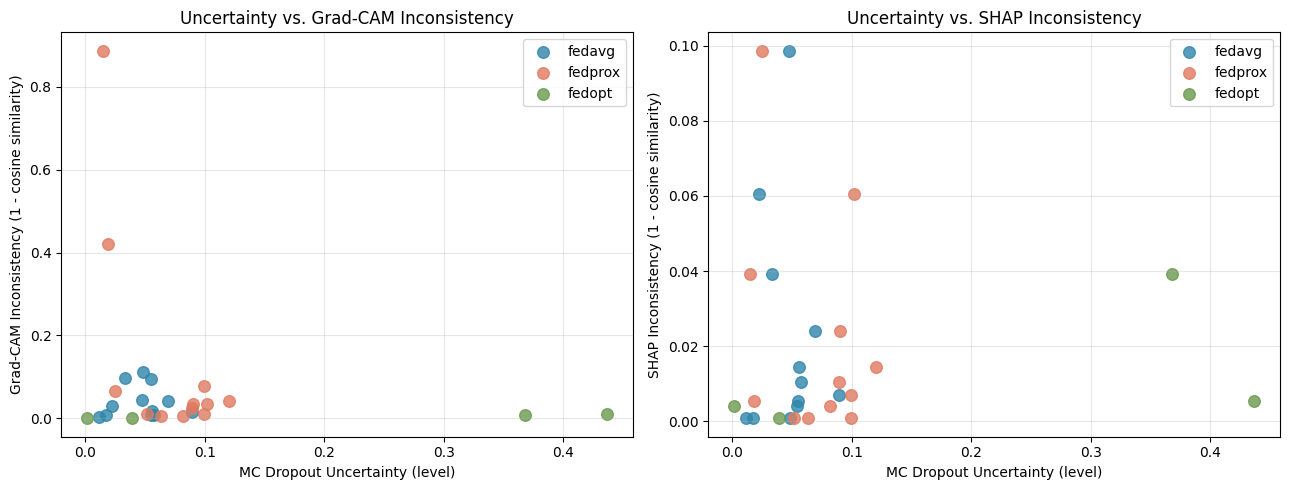

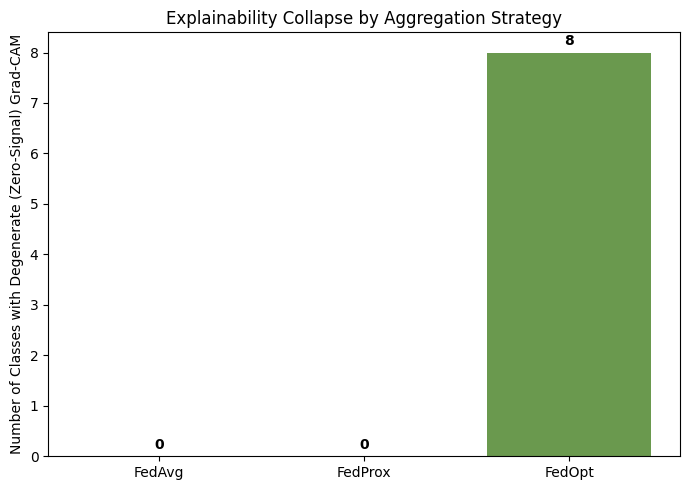

In [36]:
# Plot 1 — scatter: uncertainty vs inconsistency, colored by model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"fedavg": "#2E86AB", "fedprox": "#E07A5F", "fedopt": "#6A994E"}
for ax, (col, label) in zip(axes, [("gradcam_consistency", "Grad-CAM"), ("shap_consistency", "SHAP")]):
    for model in phase_d_clean["model"].unique():
        sub = phase_d_clean[phase_d_clean["model"] == model]
        ax.scatter(sub["uncertainty_level"], 1 - sub[col], label=model, color=colors[model], s=70, alpha=0.8)
    ax.set_xlabel("MC Dropout Uncertainty (level)")
    ax.set_ylabel(f"{label} Inconsistency (1 - cosine similarity)")
    ax.set_title(f"Uncertainty vs. {label} Inconsistency")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(rf"{FIGDIR}\phase_d_scatter.png", bbox_inches="tight")
plt.show()

# Plot 2 — degenerate class count per method
fig, ax = plt.subplots(figsize=(7, 5))
degenerate_counts = {"FedAvg": 0, "FedProx": 0, "FedOpt": 8}
ax.bar(degenerate_counts.keys(), degenerate_counts.values(), color=["#2E86AB", "#E07A5F", "#6A994E"])
ax.set_ylabel("Number of Classes with Degenerate (Zero-Signal) Grad-CAM")
ax.set_title("Explainability Collapse by Aggregation Strategy")
for i, v in enumerate(degenerate_counts.values()):
    ax.text(i, v + 0.15, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(rf"{FIGDIR}\degenerate_class_count.png", bbox_inches="tight")
plt.show()

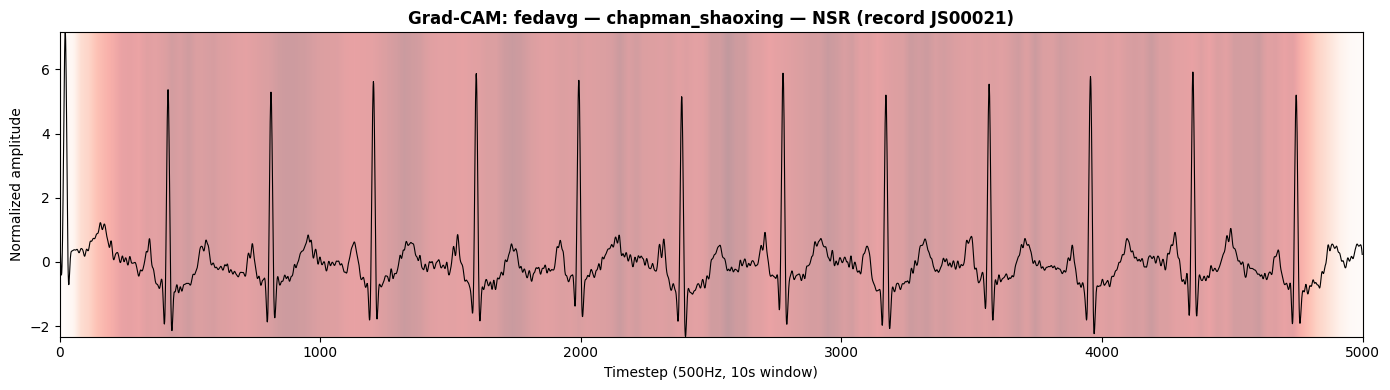

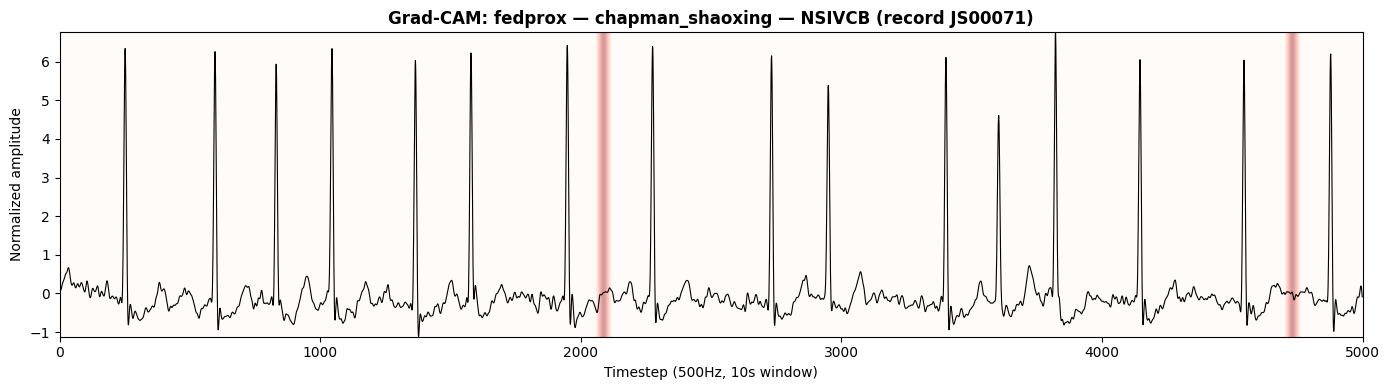

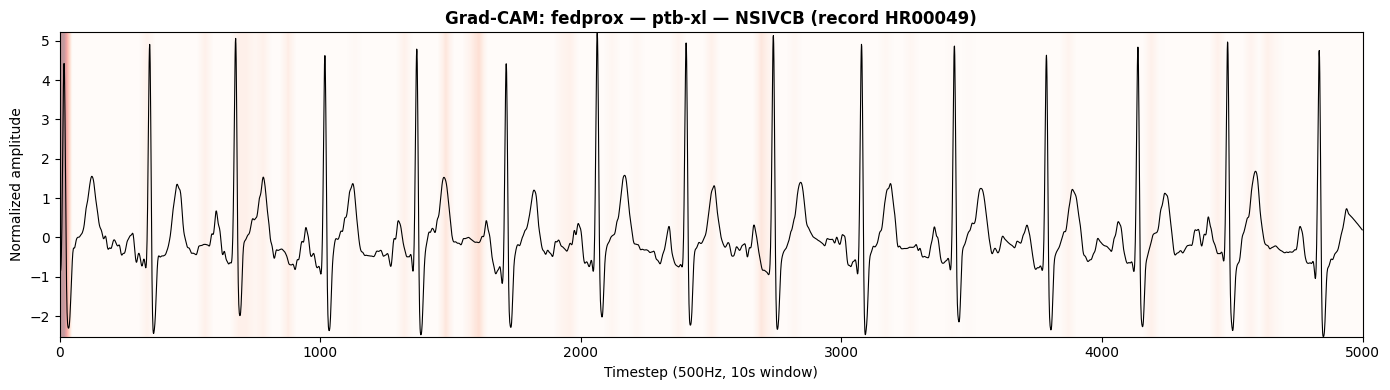

In [5]:
gradcam_data = np.load(r"C:\ECG_Project\training\stage10_gradcam\gradcam_heatmaps.npz")
def plot_gradcam_overlay(model_name, hospital, class_name, lead_idx=1):
    """Overlays a Grad-CAM heatmap on one example waveform's Lead II."""
    key = f"{model_name}__{hospital}__{class_name}"
    if key not in gradcam_data:
        print(f"Not available: {key}")
        return
    heatmap = gradcam_data[key]   # (5000,) importance over time

    # grab one real example record from this hospital/class to plot against
    metadata_df = pd.read_csv(r"C:\ECG_Project\training\ecg_metadata_train_test_split.csv")
    subset = metadata_df[(metadata_df["source_hospital"] == hospital) &
                          (metadata_df[class_name] == 1) & (metadata_df["split"] == "test")]
    record_id = subset.iloc[0]["record_id"]
    signal = np.load(rf"C:\ECG_Project\training\processed_signals\{record_id}.npy")[lead_idx]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(signal, color="black", linewidth=0.8, label="ECG signal (Lead II)")
    ax.imshow(heatmap[np.newaxis, :], aspect="auto", cmap="Reds", alpha=0.4,
              extent=[0, len(signal), signal.min(), signal.max()])
    ax.set_title(f"Grad-CAM: {model_name} — {hospital} — {class_name} (record {record_id})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Timestep (500Hz, 10s window)")
    ax.set_ylabel("Normalized amplitude")
    plt.tight_layout()
    plt.savefig(rf"{FIGDIR}\gradcam_overlay_{model_name}_{hospital}_{class_name}.png", bbox_inches="tight")
    plt.show()

plot_gradcam_overlay("fedavg", "chapman_shaoxing", "NSR")       # consistent, "normal" baseline
plot_gradcam_overlay("fedprox", "chapman_shaoxing", "NSIVCB")   # inconsistent case #1
plot_gradcam_overlay("fedprox", "ptb-xl", "NSIVCB")             # inconsistent case #2 -- same class, different hospital

In [17]:
FEATURE_COLS = ["mean_rr_interval", "heart_rate_bpm", "p_wave_amplitude",
                 "qrs_amplitude", "t_wave_amplitude", "pr_interval",
                 "qt_interval", "qrs_duration", "n_beats_detected"]

fiducial_df = pd.read_csv(r"C:\ECG_Project\training\ecg_fiducial_features_clean.csv")
train_df = fiducial_df[fiducial_df["split"] == "train"]
test_df = fiducial_df[fiducial_df["split"] == "test"]
X_train, y_train = train_df[FEATURE_COLS], train_df[FINAL_CLASSES]
X_test, y_test = test_df[FEATURE_COLS], test_df[FINAL_CLASSES]

# One RandomForest per class (multi-label), same 12-class structure as your ResNet
base_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
clf = MultiOutputClassifier(base_rf)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
micro_f1 = f1_score(y_test, y_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Fiducial-feature classifier — micro_f1={micro_f1:.4f}  macro_f1={macro_f1:.4f}")

joblib.dump(clf, r"C:\ECG_Project\training\fiducial_rf_classifier.pkl")
print("Saved: fiducial_rf_classifier.pkl")

Fiducial-feature classifier — micro_f1=0.6353  macro_f1=0.2638
Saved: fiducial_rf_classifier.pkl


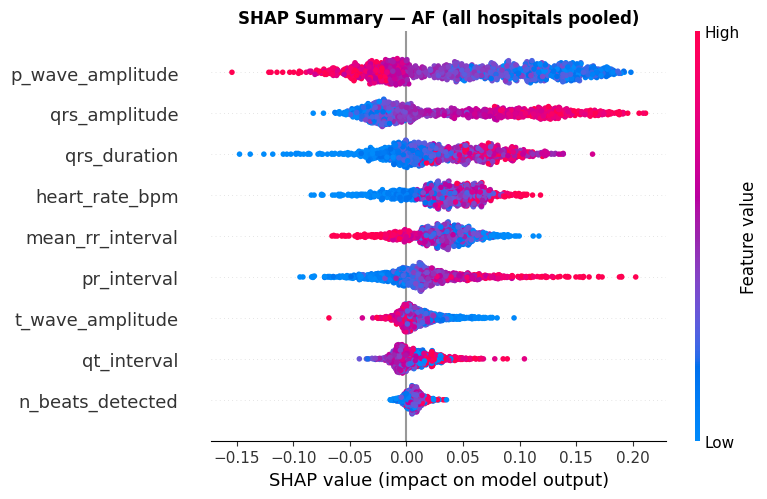

In [21]:
class_name = "AF"   # swap to inspect other diseases
class_idx = FINAL_CLASSES.index(class_name)
estimator = clf.estimators_[class_idx]
explainer = shap.TreeExplainer(estimator)

fiducial_df = pd.read_csv(r"C:\ECG_Project\training\ecg_fiducial_features_clean.csv")
test_df = fiducial_df[fiducial_df["split"] == "test"]
pos_records = test_df[test_df[class_name] == 1]

X_subset = pos_records[FEATURE_COLS]
shap_values = explainer.shap_values(X_subset)
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(sv, X_subset, feature_names=FEATURE_COLS, show=False)
plt.title(f"SHAP Summary — {class_name} (all hospitals pooled)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(rf"{FIGDIR}\shap_beeswarm_{class_name}.png", bbox_inches="tight")
plt.show()

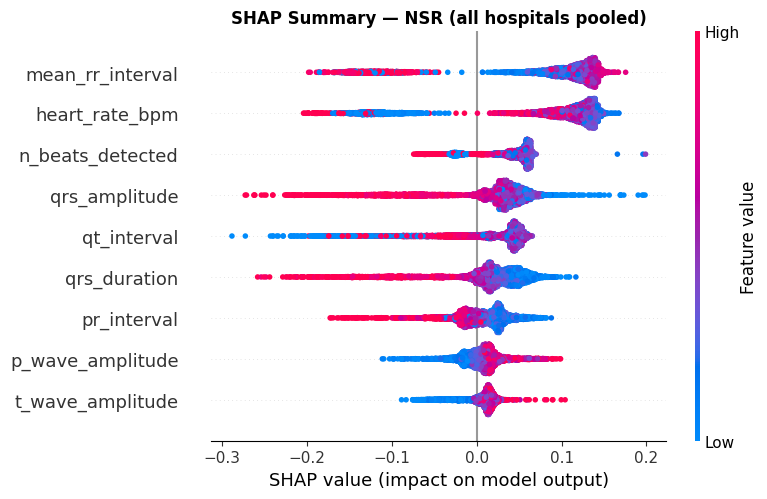

In [23]:
class_name = "NSR"   # swap to inspect other diseases
class_idx = FINAL_CLASSES.index(class_name)
estimator = clf.estimators_[class_idx]
explainer = shap.TreeExplainer(estimator)

fiducial_df = pd.read_csv(r"C:\ECG_Project\training\ecg_fiducial_features_clean.csv")
test_df = fiducial_df[fiducial_df["split"] == "test"]
pos_records = test_df[test_df[class_name] == 1]

X_subset = pos_records[FEATURE_COLS]
shap_values = explainer.shap_values(X_subset)
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(sv, X_subset, feature_names=FEATURE_COLS, show=False)
plt.title(f"SHAP Summary — {class_name} (all hospitals pooled)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(rf"{FIGDIR}\shap_beeswarm_{class_name}.png", bbox_inches="tight")
plt.show()